# 先行研究1：データの加工
## 概要
論文での推定に用いるデータの読み込みと加工を行う。

加工は、各年度の企業数を一定にする仕組みを実施している。

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside jepx-data-analytics.")
PROJECT_DIR = (
    REPO_ROOT / "Merton_Poisson_Lognormal_Model_Study_and_Negative_Binomial_Extension"
)
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)

numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.9.4


In [2]:
import sys
from pathlib import Path

# projectルートを追加
sys.path.append(str(PROJECT_DIR))

In [3]:
# make dataframe
from src.data_loader import load_csv_with_datetime_index

df = load_csv_with_datetime_index(
    (RAW_DATA_DIR / "default_counts/M.csv"),
    date_col="Year",
    date_format="%Y",
)

=== CSV loaded ===
shape: (99, 7)
columns: ['Year', 'SG', 'D_SG', 'IG', 'D_IG', 'ALL', 'D_ALL']
=== DatetimeIndex set ===
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['1920-01-01', '1921-01-01', '1922-01-01', '1923-01-01',
               '1924-01-01'],
              dtype='datetime64[ns]', name='Year', freq=None)


# モデル
潜在マクロ因子の確率モデル
$$
y_t \sim \mathcal{N}(0,1)\ ,\ d_i = \mathbb{E}[y_t y_{t+i}]
$$
マートンモデル近似後の条件付きデフォルト数分布
$$
X_t|y_t \sim \text{Poisson}(\lambda_t)\ , \ \lambda_t = \lambda_0 \exp{(\alpha y_t)} \sim \mathcal{LN}(\log \lambda_0 , \alpha^2)
$$
ただし、
$$
\alpha^2 = \frac{\rho_A}{1-\rho_A}\beta^2 \ , \ \beta=1.596
$$
ここで$\rho_A$は、標準化された企業の資産を$U_{it}$($i$は企業、$t$は時間)として
$$
U_{it} = \sqrt{\rho_A} y_t + \sqrt{1-\rho_A}\epsilon_{it}
$$

## Figure4の再現

投資適格（IG）、
投機的格付け（SG）

各年度の企業数を一致させるために以下の加工を行う
$$
k^{*}_t = 3000\frac{k_t}{n_t}
$$

In [4]:
# raw data
df.head()

,SG,D_SG,IG,D_IG,ALL,D_ALL
Year,,,,,,
1920-01-01,831,25,1843,8,2674,33
1921-01-01,1163,25,1833,7,2996,32
1922-01-01,1305,23,1972,10,3277,33
1923-01-01,1290,22,2068,5,3358,27
1924-01-01,1297,37,2175,3,3472,40


In [5]:
# normalization
df["SG_norm"] = df["D_SG"] / df["SG"] * 3000
df["IG_norm"] = df["D_IG"] / df["IG"] * 3000
df["ALL_norm"] = df["D_ALL"] / df["ALL"] * 3000

# view dataframe
df.head()

,SG,D_SG,IG,D_IG,ALL,D_ALL,SG_norm,IG_norm,ALL_norm
Year,,,,,,,,,
1920-01-01,831,25,1843,8,2674,33,90.252708,13.022246,37.023186
1921-01-01,1163,25,1833,7,2996,32,64.488392,11.456628,32.042724
1922-01-01,1305,23,1972,10,3277,33,52.873563,15.212982,30.210558
1923-01-01,1290,22,2068,5,3358,27,51.162791,7.253385,24.121501
1924-01-01,1297,37,2175,3,3472,40,85.582113,4.137931,34.562212


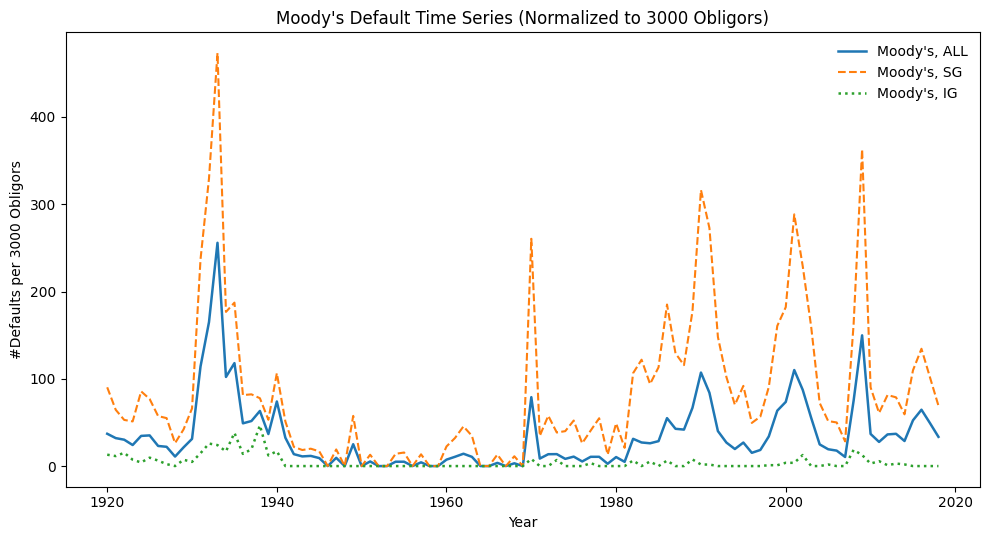

In [6]:
# Figure 4
plt.figure(figsize=(10, 5.5))
plt.plot(df.index, df["ALL_norm"], label="Moody's, ALL", linewidth=1.8)
plt.plot(df.index, df["SG_norm"], "--", label="Moody's, SG", linewidth=1.5)
plt.plot(df.index, df["IG_norm"], ":", label="Moody's, IG", linewidth=1.8)

plt.title("Moody's Default Time Series (Normalized to 3000 Obligors)")
plt.xlabel("Year")
plt.ylabel("#Defaults per 3000 Obligors")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()